In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics, model_selection, linear_model




In [2]:
def laplace_likelihood(y, p):
    m, s = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.maximum(70, s)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)


def laplace_likelihood_bound(y, p):
    m = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.maximum(70, np.sqrt(2) * diff)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)


def laplace_likelihood_avg(y, p):
    m = p
    diff = np.minimum(1000, np.abs(y - m))
    s = np.sqrt(2) * metrics.mean_absolute_error(y, m)
    lik = -np.sqrt(2) * diff / s - np.log(np.sqrt(2) * s)
    return np.mean(lik)




In [3]:
def build_folds(X, y, group=None, k=5, shuffle=False, train_mask=None, valid_mask=None):
    if isinstance(X, pd.DataFrame):
        X = X.values
    if isinstance(y, pd.DataFrame):
        y = y.values
    if isinstance(group, pd.DataFrame):
        group = group.values
    if isinstance(train_mask, pd.DataFrame):
        train_mask = train_mask.values
    if isinstance(valid_mask, pd.DataFrame):
        valid_mask = valid_mask.values
    if group is None:
        folds = list(model_selection.KFold(k, shuffle=True).split(X, y))
    else:
        idx = np.random.permutation(np.arange(X.shape[0]))
        if shuffle:
            Xs, ys, groups = X.copy()[idx], y.copy()[idx], group.copy()[idx]
            folds = list(
                model_selection.GroupKFold(k).split(
                    np.array(Xs), np.array(ys), np.array(groups)
                )
            )
        else:
            folds = list(model_selection.GroupKFold(k).split(X, y, group))
    if train_mask is not None:
        for i in range(k):
            folds[i] = (
                np.array([j for j in folds[i][0] if train_mask[j]]),
                folds[i][1],
            )
    if valid_mask is not None:
        for i in range(k):
            folds[i] = (
                folds[i][0],
                np.array([j for j in folds[i][1] if valid_mask[j]]),
            )
    return folds




In [4]:
def feature_eng(df):
    df = df.copy()
    df["n_weeks"] = df["Weeks_target"] - df["Weeks_base"]
    df["Sex_female"] = (df["Sex"] == "Female").astype("float")
    df["Smoking_ex"] = (df["SmokingStatus"] == "Ex-smoker").astype(int)
    df["Smoking_currently"] = (df["SmokingStatus"] == "Currently smokes").astype(int)
    return df




In [5]:
data_folder = "../input/osic-pulmonary-fibrosis-progression"



In [6]:
df_train = pd.read_csv(os.path.join(data_folder, "train.csv")).drop_duplicates(
    keep=False, subset=["Patient", "Weeks"]
)

df_train["n_obs"] = df_train.groupby("Patient").Weeks.cumcount()
df_train["till_last"] = (
    df_train.groupby("Patient").Weeks.transform("count") - 1 - df_train["n_obs"]
)

df_train = df_train.merge(
    df_train.drop(["Age", "Sex", "Percent", "SmokingStatus"], axis=1),
    on="Patient",
    suffixes=["_base", "_target"],
)

df_train = feature_eng(df_train)
FEATURES = [
    "n_weeks",
    "FVC_base",
    "Percent",
    "Age",
    "Sex_female",
    "Smoking_ex",
    "Smoking_currently",
]

df_train.head(2)



,Patient,Weeks_base,FVC_base,Percent,Age,Sex,SmokingStatus,n_obs_base,till_last_base,Weeks_target,FVC_target,n_obs_target,till_last_target,n_weeks,Sex_female,Smoking_ex,Smoking_currently
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked,0,8,-2,3195,0,8,0,0.0,0,0
1,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked,0,8,2,3203,1,7,4,0.0,0,0


In [7]:
train_mask = (
    (df_train.n_weeks > 0)
    & df_train.n_obs_base.between(0, 0)
    & df_train.till_last_target.between(0, 100)
)
valid_mask = (
    (df_train.n_weeks > 0)
    & df_train.n_obs_base.between(0, 0)
    & df_train.till_last_target.between(0, 2)
)



In [8]:
df_test = pd.read_csv(os.path.join(data_folder, "test.csv")).rename(
    columns={"Weeks": "Weeks_base", "FVC": "FVC_base"}
)

df_test = (
    df_test.assign(k=0)
    .merge(pd.DataFrame({"Weeks_target": np.arange(-12, 133 + 1), "k": 0}), on="k")
    .drop("k", axis=1)
)

df_test = feature_eng(df_test)

df_test.head(2)



,Patient,Weeks_base,FVC_base,Percent,Age,Sex,SmokingStatus,Weeks_target,n_weeks,Sex_female,Smoking_ex,Smoking_currently
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker,-12,-12,0.0,1,0
1,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker,-11,-11,0.0,1,0


In [9]:
print(100 * "#")
print(
    "Train: %4d rows with %3d unique patients"
    % (df_train[train_mask].shape[0], df_train[train_mask].Patient.nunique())
)
print(
    "Valid: %4d rows with %3d unique patients"
    % (df_train[valid_mask].shape[0], df_train[valid_mask].Patient.nunique())
)
print(
    "Test:  %4d rows with %3d unique patients"
    % (df_test.shape[0], df_test.Patient.nunique())
)
print(100 * "#")



####################################################################################################
Train: 1222 rows with 158 unique patients
Valid:  474 rows with 158 unique patients
Test:  2628 rows with  18 unique patients
####################################################################################################


In [10]:
X = df_train[FEATURES].copy()
y = df_train["FVC_target"].copy()
X_test = df_test[FEATURES].copy()



In [11]:
model = linear_model.LinearRegression()
model.fit(X[train_mask], y[train_mask])
pred_mean = model.predict(X)
test_mean = model.predict(X_test)



(array([1492., 1453., 1243., 1062.,  986.,  767.,  713.,  574.,  547.,
         447.,  379.,  348.,  311.,  251.,  215.,  185.,  150.,  131.,
          97.,  109.,   82.,   44.,   61.,   41.,   29.,   47.,   31.,
          19.,   27.,   21.,   22.,   16.,   10.,   14.,   15.,   11.,
           8.,   12.,   12.,    7.,    9.,   15.,   16.,    6.,    4.,
           4.,    6.,    7.,    4.,   76.]),
 array([1.64555006e-03, 2.82858839e+01, 5.65701222e+01, 8.48543606e+01,
        1.13138599e+02, 1.41422837e+02, 1.69707076e+02, 1.97991314e+02,
        2.26275552e+02, 2.54559791e+02, 2.82844029e+02, 3.11128267e+02,
        3.39412506e+02, 3.67696744e+02, 3.95980982e+02, 4.24265221e+02,
        4.52549459e+02, 4.80833697e+02, 5.09117936e+02, 5.37402174e+02,
        5.65686412e+02, 5.93970651e+02, 6.22254889e+02, 6.50539127e+02,
        6.78823366e+02, 7.07107604e+02, 7.35391842e+02, 7.63676081e+02,
        7.91960319e+02, 8.20244557e+02, 8.48528796e+02, 8.76813034e+02,
        9.05097272e+02, 

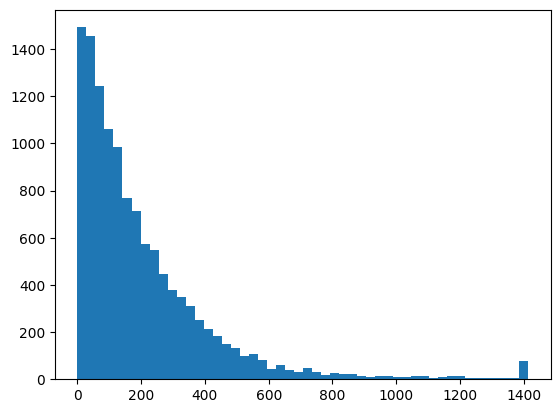

In [12]:
opt_sigma = np.sqrt(2) * np.clip(np.abs(y - pred_mean), 0, 1000)
plt.hist(opt_sigma, 50)



In [13]:
model = linear_model.LinearRegression()
model.fit(X[train_mask], opt_sigma[train_mask])
pred_sigma = model.predict(X)
test_sigma = model.predict(X_test)



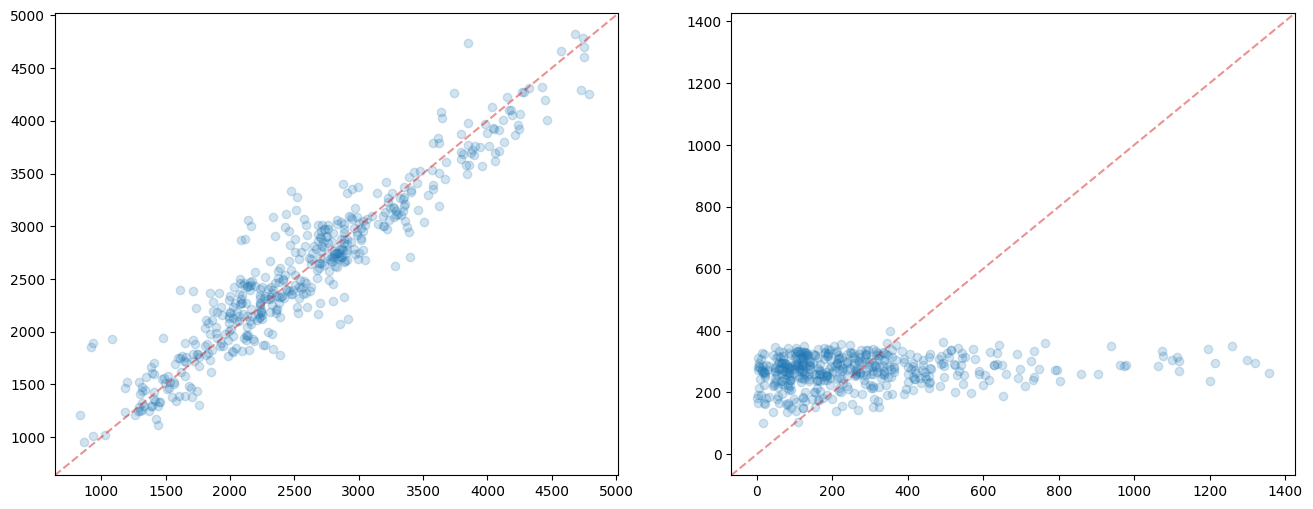

In [14]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.scatter(y[valid_mask], pred_mean[valid_mask], alpha=0.2)
plt.xlim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.ylim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.plot(plt.xlim(), plt.ylim(), color="tab:red", alpha=0.5, linestyle="--")
plt.subplot(1, 2, 2)
plt.scatter(opt_sigma[valid_mask], pred_sigma[valid_mask], alpha=0.2)
plt.xlim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.ylim(min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1]))
plt.plot(plt.xlim(), plt.ylim(), color="tab:red", alpha=0.5, linestyle="--")



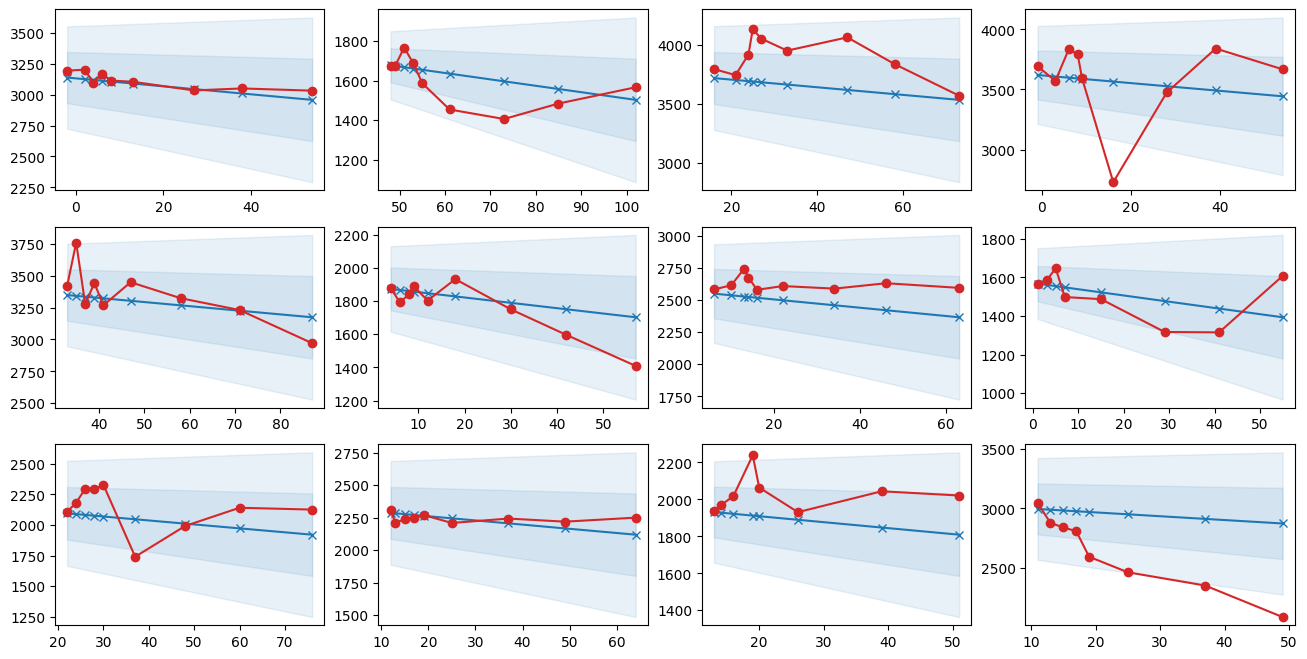

In [15]:
plt.figure(figsize=(16, 8))
for i, pid in enumerate(df_train[valid_mask].Patient.unique()[:12]):
    plt.subplot(3, 4, i + 1)
    idx = (df_train.Patient == pid) & (df_train.n_obs_base == 0)
    plt.fill_between(
        df_train[idx].Weeks_target,
        pred_mean[idx] - 1 * pred_sigma[idx],
        pred_mean[idx] + 1 * pred_sigma[idx],
        color="tab:blue",
        alpha=0.1,
    )
    plt.fill_between(
        df_train[idx].Weeks_target,
        pred_mean[idx] - 2 * pred_sigma[idx],
        pred_mean[idx] + 2 * pred_sigma[idx],
        color="tab:blue",
        alpha=0.1,
    )
    plt.plot(df_train[idx].Weeks_target, pred_mean[idx], marker="x", color="tab:blue")
    plt.plot(
        df_train[idx].Weeks_target,
        df_train[idx].FVC_target,
        marker="o",
        color="tab:red",
    )



In [16]:
# Change 1 (score/validity): enforce strictly positive, finite Confidence values.
# The metric clips sigma at 70 but does not handle negative/NaN well; this avoids invalid submissions/poor scoring.
test_sigma = np.asarray(test_sigma, dtype=np.float64)
test_sigma = np.nan_to_num(test_sigma, nan=70.0, posinf=1000.0, neginf=70.0)
test_sigma = np.clip(test_sigma, 1.0, 1e6)

# Build raw predictions keyed by Patient_Week
pred_df = df_test.copy()[["Patient", "Weeks_target"]]
pred_df["Patient_Week"] = pred_df["Patient"] + "_" + pred_df["Weeks_target"].astype(str)
pred_df["FVC"] = np.asarray(test_mean, dtype=np.float64)
pred_df["Confidence"] = test_sigma
pred_df = pred_df[["Patient_Week", "FVC", "Confidence"]]

# Change 2 (submission correctness): align exactly to sample_submission.csv rows/order.
# Kaggle expects the exact Patient_Week list and order; merging guarantees perfect alignment.
sample_sub = pd.read_csv(os.path.join(data_folder, "sample_submission.csv"))
submission = sample_sub[["Patient_Week"]].merge(pred_df, on="Patient_Week", how="left")

# Safety: if any rows are missing due to unexpected week ranges, fill with baseline-like defaults.
submission["FVC"] = submission["FVC"].fillna(sample_sub["FVC"]).astype(float)
submission["Confidence"] = (
    submission["Confidence"].fillna(sample_sub["Confidence"]).astype(float)
)

submission.head()



,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2420.047991,148.334804
1,ID00126637202218610655908_-2,2416.820744,150.589602
2,ID00126637202218610655908_-1,2413.593497,152.844401
3,ID00126637202218610655908_0,2410.366250,155.099200
4,ID00126637202218610655908_1,2407.139003,157.353999


In [17]:
submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", submission.shape)
print(submission.head())
print(
    "Any missing predictions:", submission[["FVC", "Confidence"]].isna().any().to_dict()
)

Wrote submission.csv with shape: (1908, 3)
                   Patient_Week          FVC  Confidence
0  ID00126637202218610655908_-3  2420.047991  148.334804
1  ID00126637202218610655908_-2  2416.820744  150.589602
2  ID00126637202218610655908_-1  2413.593497  152.844401
3   ID00126637202218610655908_0  2410.366250  155.099200
4   ID00126637202218610655908_1  2407.139003  157.353999
Any missing predictions: {'FVC': False, 'Confidence': False}
